# Notebook Description

This notebook contains the code used to generate the synthetic train ensemble dataset shown in **Figure 4** of the paper. We construct data assumed to be sampled from a network under two distinct stimuli. We demonstrate that network-level activity carries sufficient information to classify the stimuli, whereas individual neurons fail to reliably do so.

Refer to Section **4.2 Results Using Synthetic Data**, *TDA Discerns Patterns in Network Activity That Are Not Present in Individual Neurons*, for a detailed explanation.


In [1]:
# load all our tools
from utils import*

# Spike Train Templates

Below we generate 7 template spike trains from which we build template train ensembles.

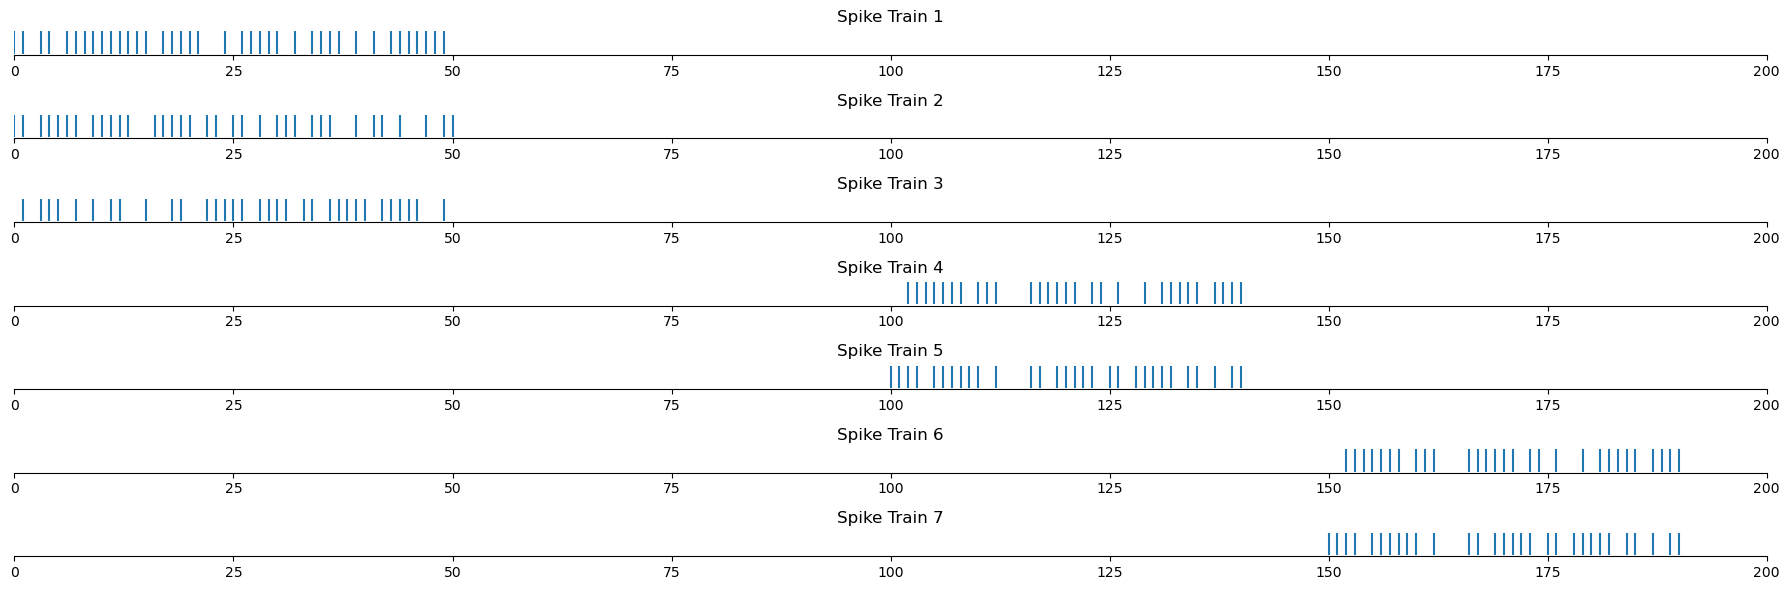

In [2]:
# ==== Generating Template Spike Trains ===
universal_random_state = 1 # fix a universal random seed that will be the key to reproducing everything that follows in this notebook.
## spike train templates 
fire_rate = 0.7
st_temp1 = gen_spike_train(T = 300, prob_map= [(0,50,fire_rate)],random_state = universal_random_state + 1) # fires from 0 to 50 ms with prob fire_rate
st_temp2 = gen_spike_train(T = 300, prob_map = [(0,50,fire_rate)],random_state = universal_random_state + 2)# fires from 0 to 50 ms with prob fire_rate
st_temp3 = gen_spike_train(T = 300, prob_map =[(0,50,fire_rate)], random_state = universal_random_state + 3) # fires from 0 to 50 ms with prob fire_rate
st_temp4 = gen_spike_train(T = 300, prob_map = [(100,140,fire_rate)],random_state = universal_random_state + 4) # fires from 100 to 140 ms with prob fire_rate
st_temp5 = gen_spike_train(T = 300, prob_map = [(100,140,fire_rate)],random_state = universal_random_state + 5) # fires from 100 to 140 ms with prob fire_rate
st_temp6 = shift_spike_train(st_temp4, shift_amount = 50) # identical to st_temp4 but shifted by 50 ms
st_temp7 = shift_spike_train(st_temp5, shift_amount = 50) # identical to st_temp5 but shifted by 50 ms


fig, axes = plt.subplots(7,1, figsize = (18,6))
ax = axes[0]
plot_spike_train(st_temp1,axes =ax)
ax.set_xlim(0,200)
ax.set_title('Spike Train 1')

ax = axes[1]
plot_spike_train(st_temp2,axes =ax)
ax.set_xlim(0,200)
ax.set_title('Spike Train 2')

ax = axes[2]
plot_spike_train(st_temp3,axes =ax)
ax.set_xlim(0,200)
ax.set_title('Spike Train 3')

ax = axes[3]
plot_spike_train(st_temp4,axes =ax)
ax.set_xlim(0,200)
ax.set_title('Spike Train 4')

ax = axes[4]
plot_spike_train(st_temp5,axes =ax)
ax.set_xlim(0,200)
ax.set_title('Spike Train 5')

ax = axes[5]
plot_spike_train(st_temp6,axes =ax)
ax.set_xlim(0,200)
ax.set_title('Spike Train 6')

ax = axes[6]
plot_spike_train(st_temp7,axes =ax)
ax.set_xlim(0,200)
ax.set_title('Spike Train 7')


plt.tight_layout()
plt.show()

# Raster Templates

Using the 7 spike train templates defined above, we generate 4 raster templates. The first two will be labeled as stimulus 1, and the other two as stimulus 2.

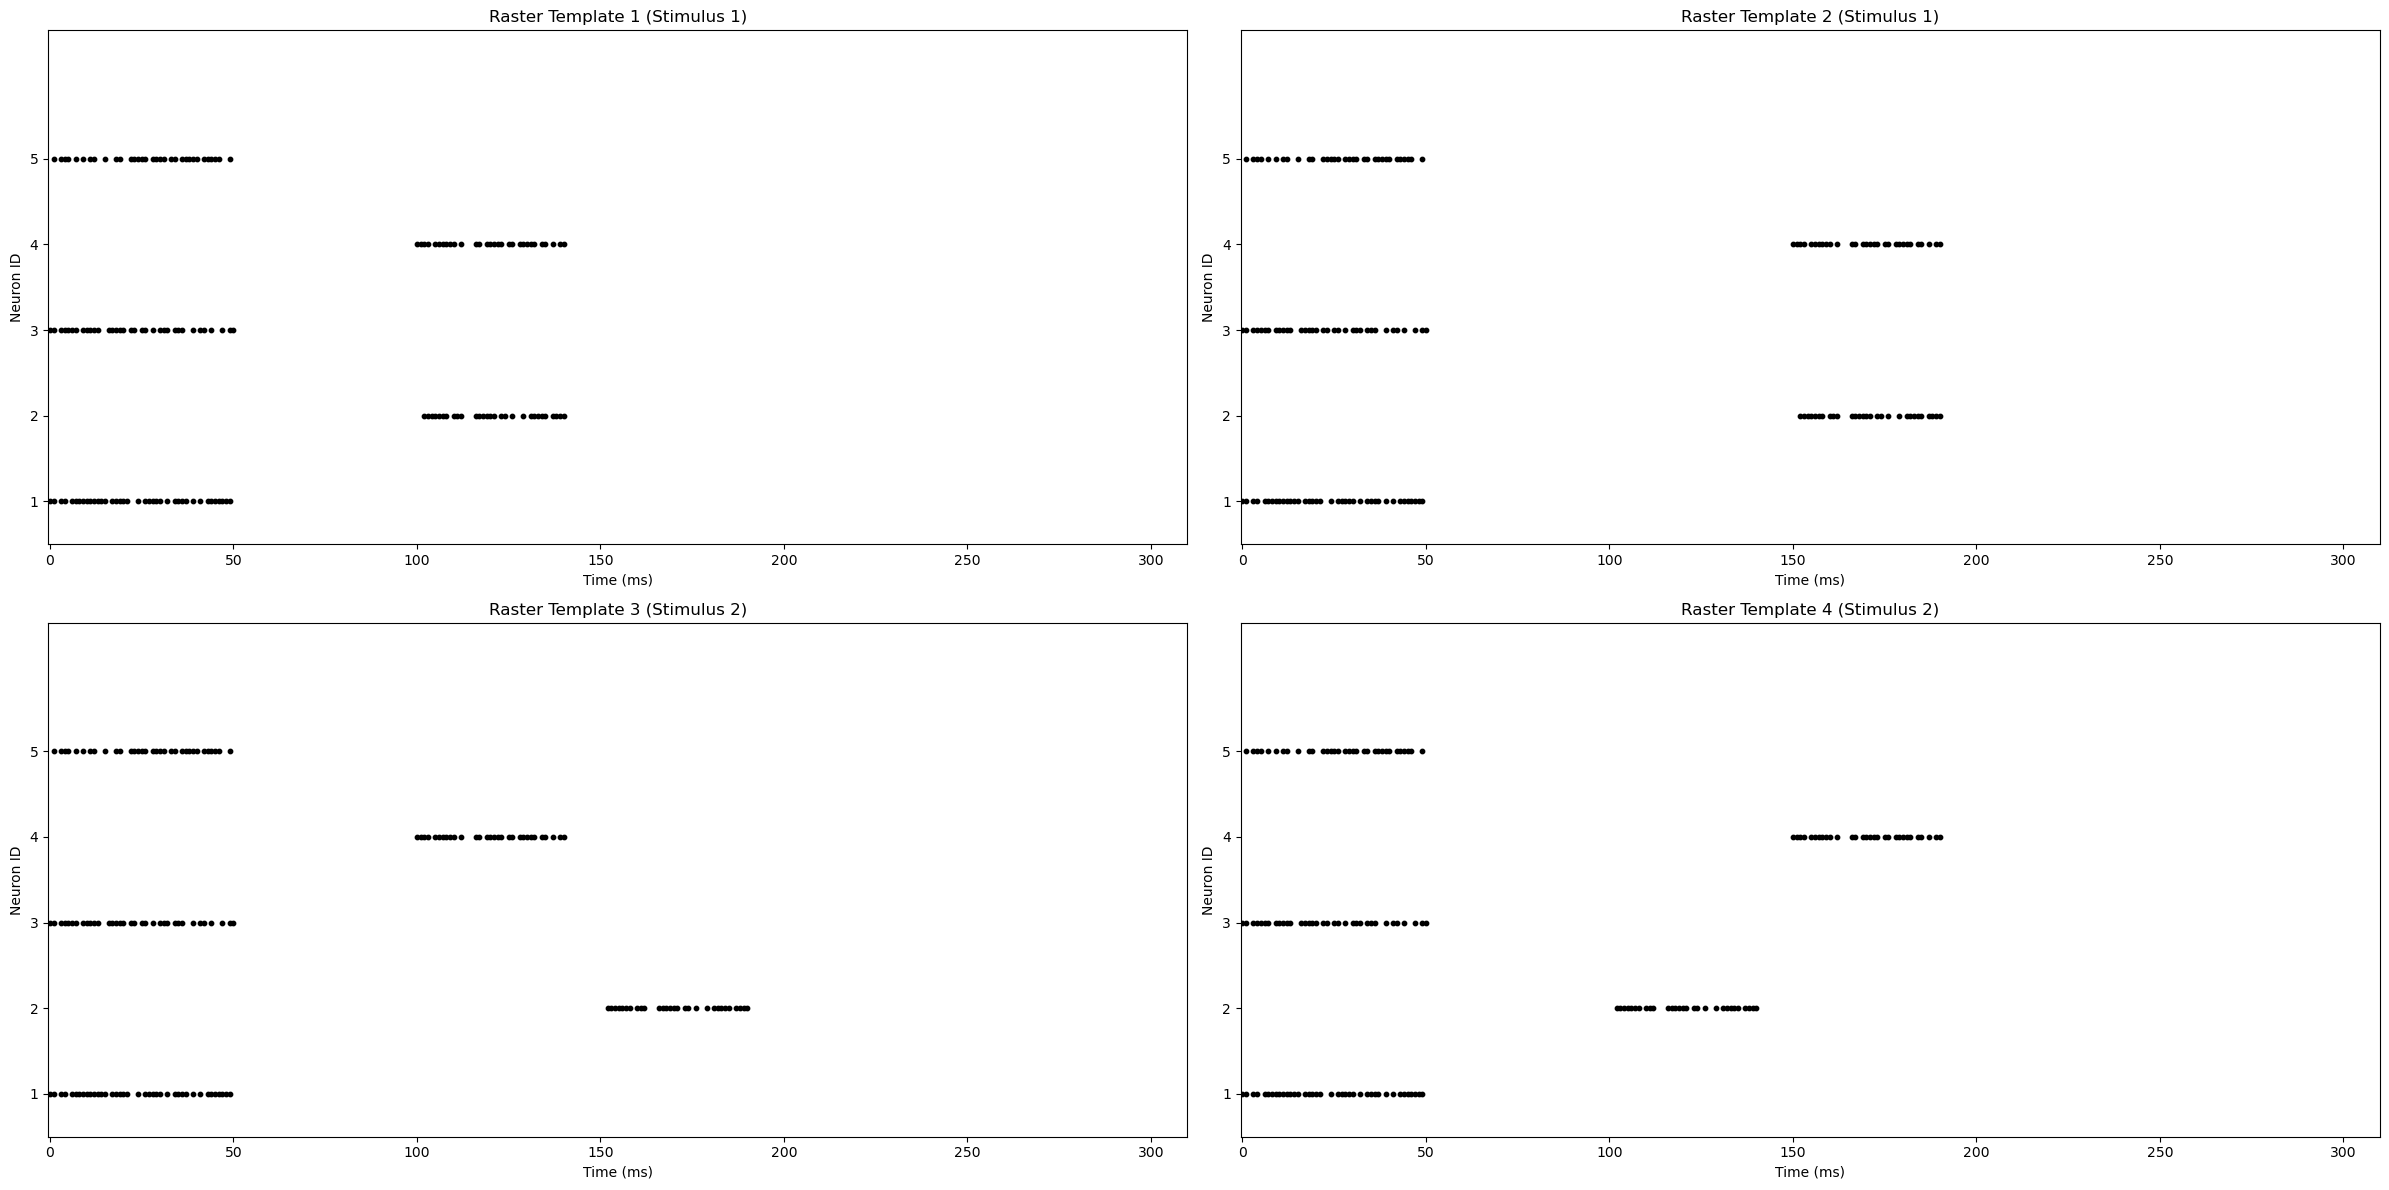

In [3]:
#  ==== Creating raster templates ====
## stimulus 1 templates
### stim 1 will have two templates; first one will have st_temp1, st_temp4, st_temp2, st_temp5, st_temp3 in order from bottom to top. 
### Raster Template 1
raster_temp1 = np.array([st_temp1,st_temp4,st_temp2,st_temp5,st_temp3]) # this is the first template for stimulus 1. It will have st_temp1, st_temp4, st_temp2, st_temp5 ,st_temp3 in order from bottom to top.
                    
### Raster Template 2; this is the second template for stimulus 1. It will have st_temp1, st_temp6, st_temp2, st_temp7 ,st_temp3 in order from bottom to top.
raster_temp2 = np.array([st_temp1,st_temp6,st_temp2,st_temp7,st_temp3]) 

## stimulus 2 templates; this will also have two templates;
### Raster Template 3; this is the first template for stimulus 2. It will have st_temp1, st_temp6, st_temp2, st_temp5, st_temp3 in order from bottom to top.
raster_temp3 = np.array([st_temp1,st_temp6,st_temp2,st_temp5,st_temp3]) # this is the first template for stimulus 2. It will have st_temp1, st_temp6, st_temp2, st_temp5 ,st_temp3 in order from bottom to top.

### Raster Template 4; this is the second template for stimulus 2. It will have st_temp1, st_temp4, st_temp2, st_temp7, st_temp3 in order from bottom to top.
raster_temp4 = np.array([st_temp1,st_temp4,st_temp2,st_temp7,st_temp3])


fig, axs = plt.subplots(2,2,figsize = (24,12))


ax = axs[0][0]
plot_raster(raster_temp1,axes = ax)
ax.set_title('Raster Template 1 (Stimulus 1)')

ax = axs[0][1]
plot_raster(raster_temp2,axes = ax)
ax.set_title('Raster Template 2 (Stimulus 1)')

ax = axs[1][0]
plot_raster(raster_temp3,axes = ax)
ax.set_title('Raster Template 3 (Stimulus 2)')

ax = axs[1][1]
plot_raster(raster_temp4,axes = ax)
ax.set_title('Raster Template 4 (Stimulus 2)')

plt.tight_layout()
plt.show()

# Template Barcodes
We compute the barcodes for the 4 raster templates. Note that template 1 and 2 share the same barcode even though they are different rasters. The same holds true for templates 3 and 4. This gives us some intuition about the fiber of the persistence homology map. This happens because the Victor-Purpura distance does not change with the translation of the spike trains.

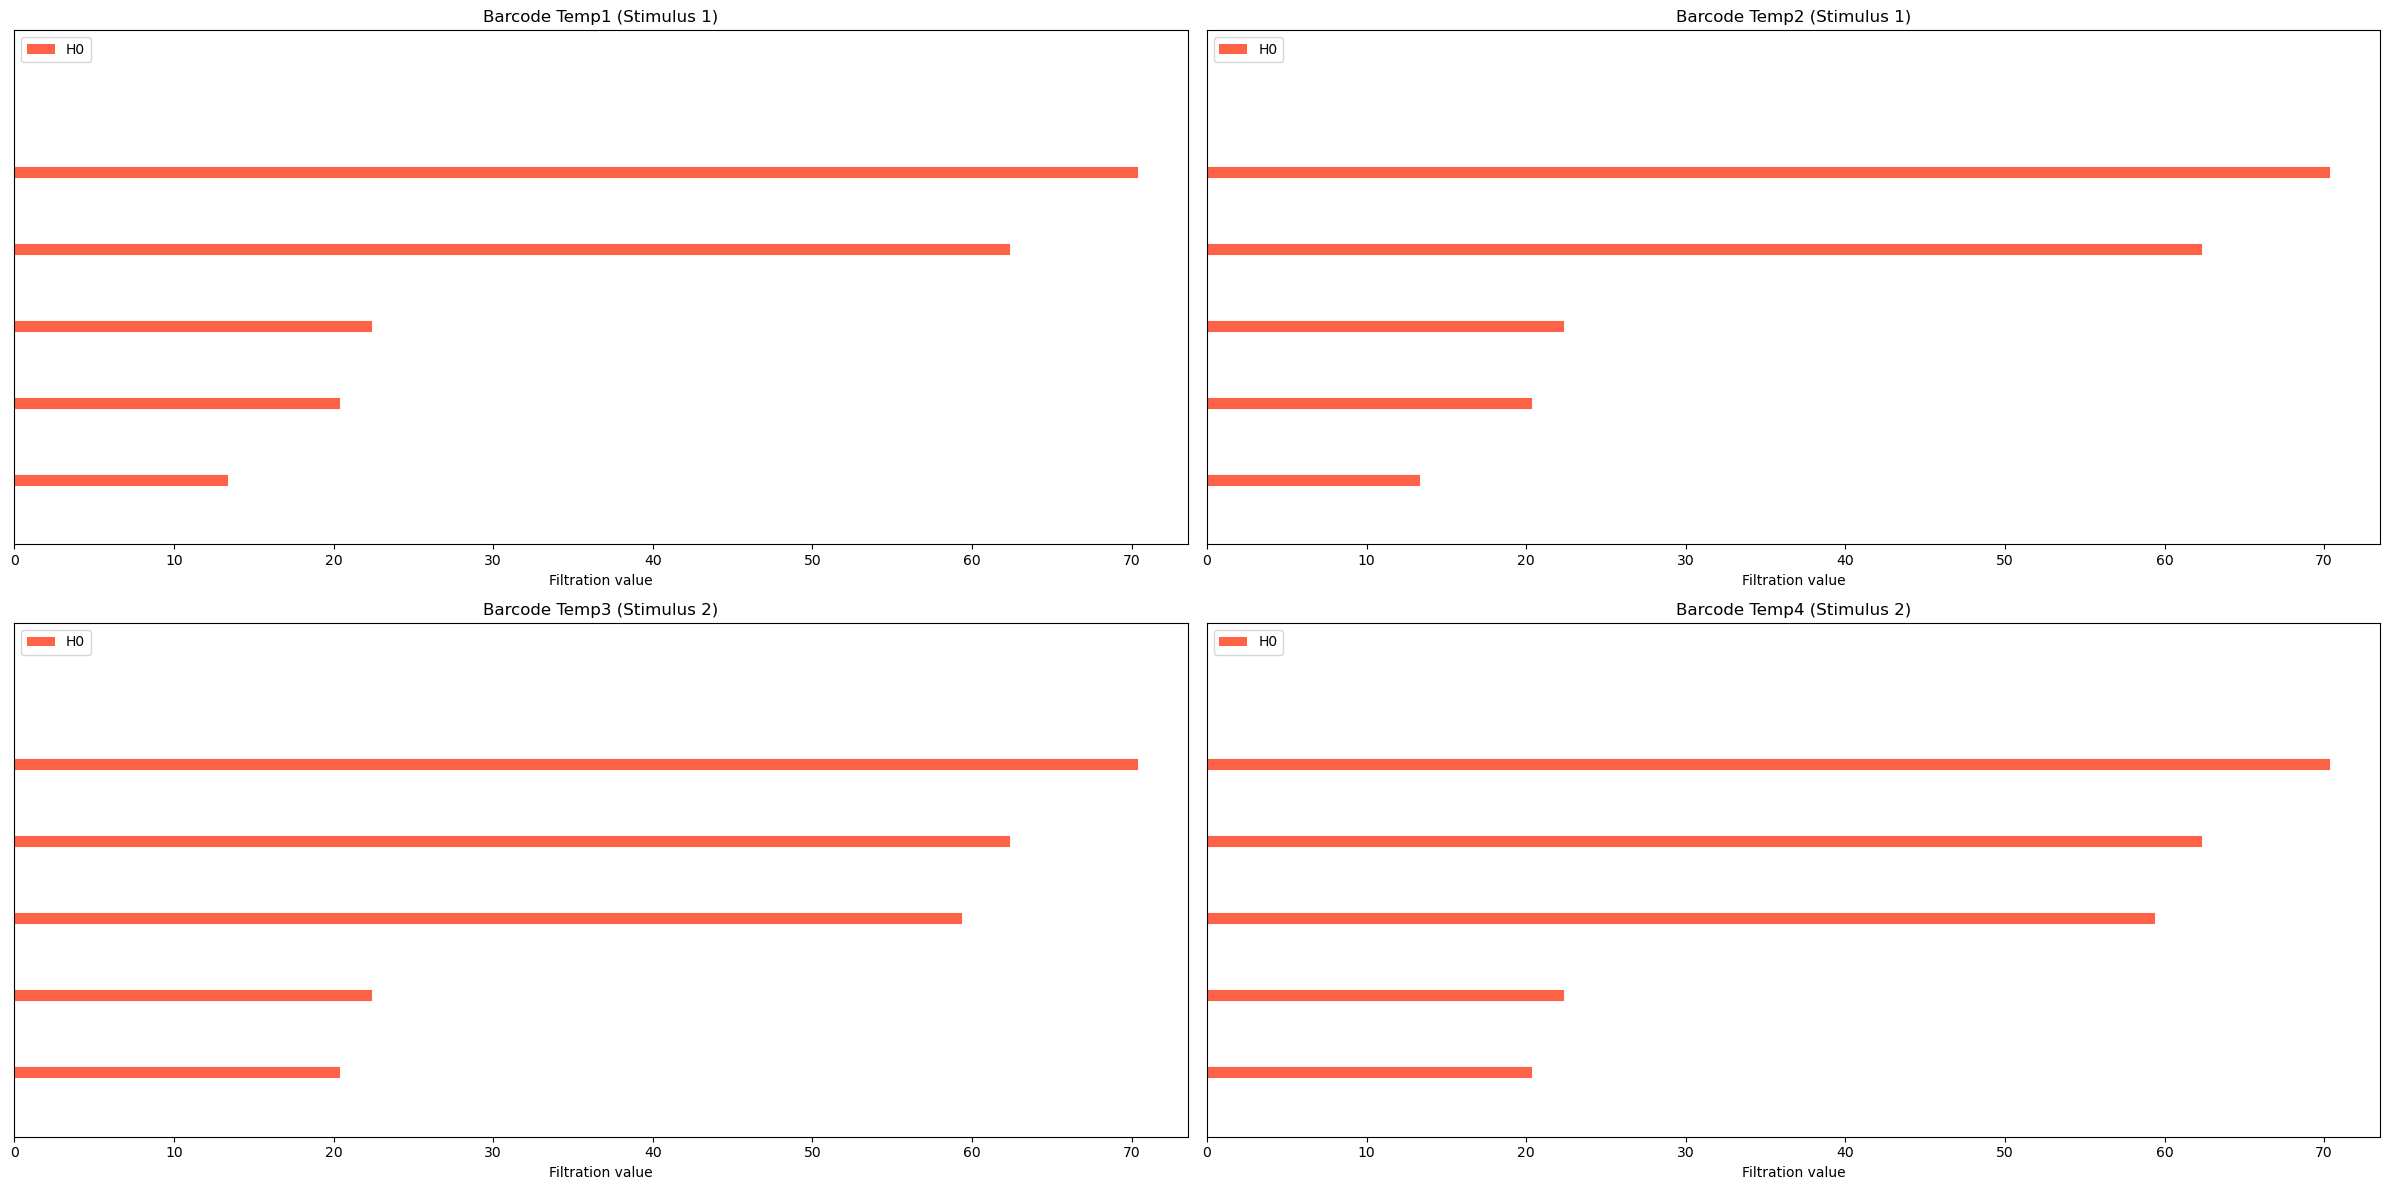

In [4]:
# template barcodes
barcode_temp1 = compute_barcode_from_raster(raster_temp1)
barcode_temp2 = compute_barcode_from_raster(raster_temp2)
barcode_temp3 = compute_barcode_from_raster(raster_temp3)
barcode_temp4 = compute_barcode_from_raster(raster_temp4)


fig, axs = plt.subplots(2,2, figsize = (24,12))

ax = axs[0][0]
plot_barcode(barcode_temp1,ax = ax,r = 70)
ax.set_title('Barcode Temp1 (Stimulus 1)')

ax = axs[0][1]
plot_barcode(barcode_temp2,ax = ax,r = 70)
ax.set_title('Barcode Temp2 (Stimulus 1)')

ax = axs[1][0]
plot_barcode(barcode_temp3,ax = ax,r = 70)
ax.set_title('Barcode Temp3 (Stimulus 2)')

ax = axs[1][1]
plot_barcode(barcode_temp4,ax = ax,r = 70)
ax.set_title('Barcode Temp4 (Stimulus 2)')

plt.tight_layout()
plt.show()

# Generating the Synthetic Datasets Using the Template Rasters
We now generate a dataset using the template rasters. This dataset will consist of 200 trials (rasters) equally distributed between all the templates. We will have 100 trials for stimulus 1 and 100 trials for stimulus 2. Each trial is generated by adding noise to the template rasters. The noise strength can be adjusted to control the variability of the trials. By noise, we mean either adding or removing spikes or shifting spikes in time.

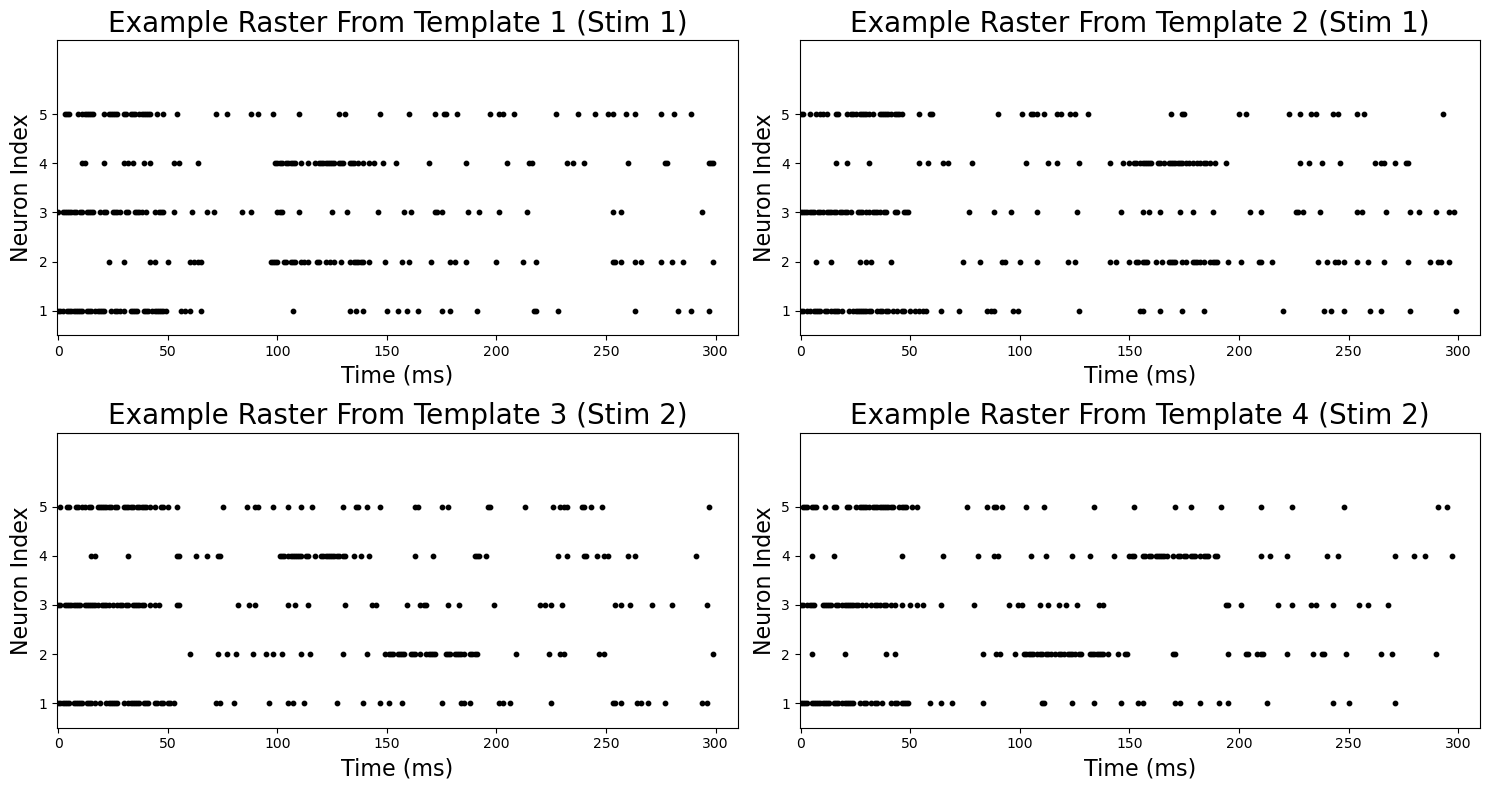

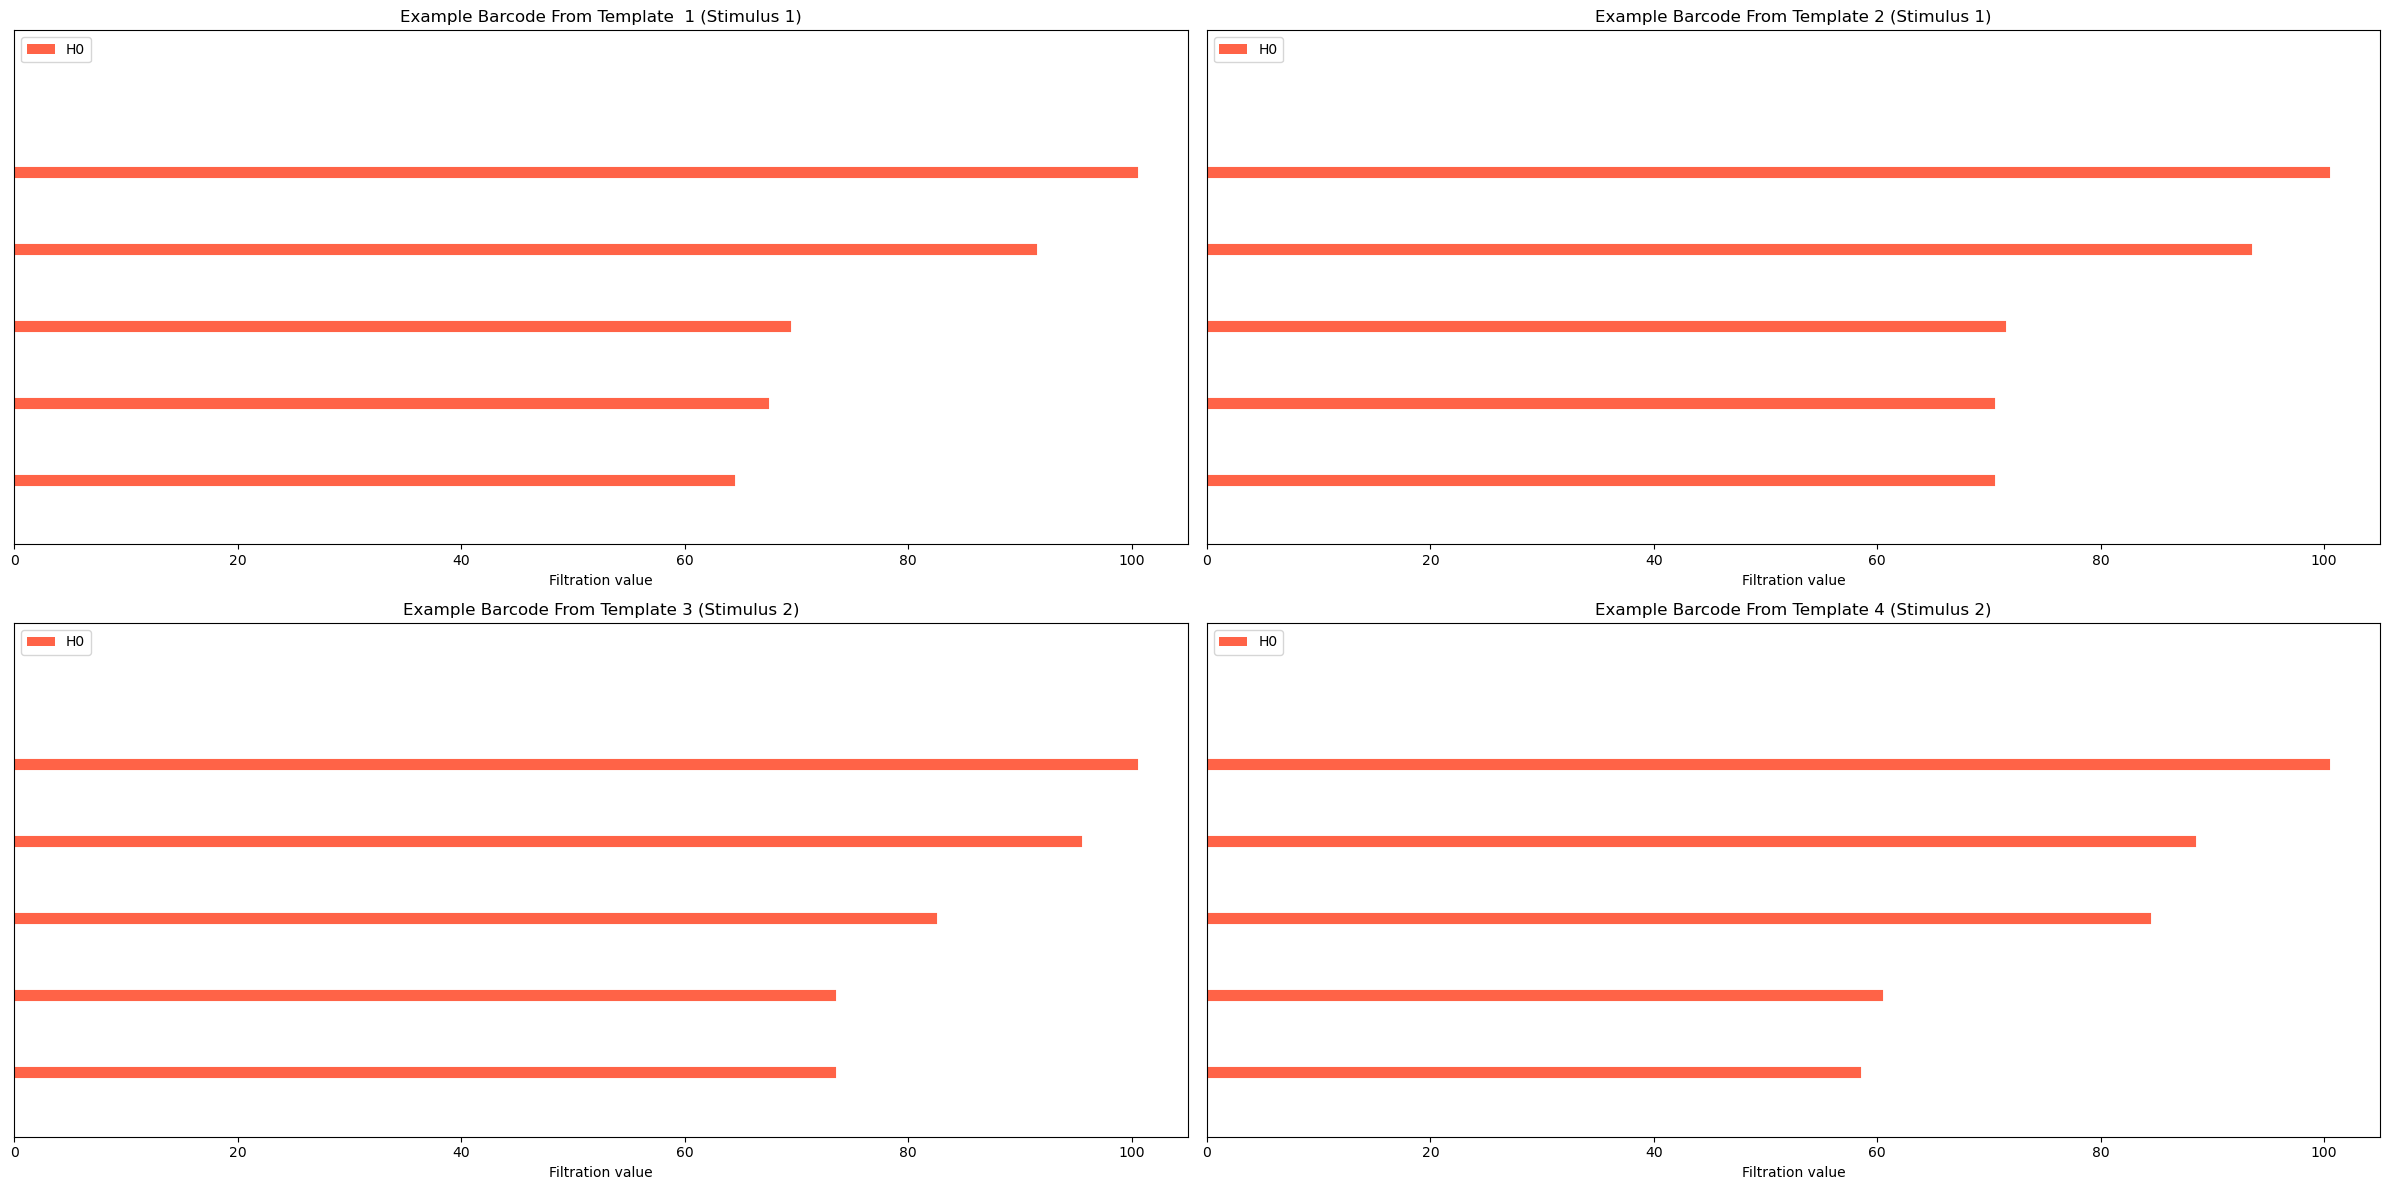

In [5]:
# Generate dataset using the template rasters
n_samples_per_template = 50 # Note: 2*n_samples_per_template will give number of samples per stimulus
rng = np.random.default_rng(universal_random_state) 

# Create a large pool of unique numbers and shuffle it
total_samples = 4 * n_samples_per_template
shuffled_pool = rng.permutation(total_samples)

# Split the shuffled pool into four disjoint lists of random seeds
random_list1, random_list2, random_list3, random_list4 = np.split(shuffled_pool, 4)
random_list = rng.choice(n_samples_per_template, size=n_samples_per_template, replace=False) # list of random seeds. This is also reproducible with the universal_random_state.

# parameters for noise addition
# the noise order is Remove -> Shift -> Add
noise_level_remove = 0.1 # probability of each spike being removed
noise_level_shift = 1.0 # probability of each spike being shifted
shift_strength = 5 # bounds of the shift in ms; if shift_strength = 5, then each spike can be shifted by x ms where x is uniformly sampled from [-5, 5].
noise_level_add = 0.1 # probability of a spike being added to an empty time slot.

# stim 1 rasters
rasters1 = [add_noise_to_raster(raster_temp1,noise_level_shift=noise_level_shift,shift_strength= shift_strength, noise_level_add= noise_level_add, noise_level_remove= noise_level_remove,random_state = random_seed) for random_seed in random_list1]
rasters2 = [add_noise_to_raster(raster_temp2,noise_level_shift=noise_level_shift,shift_strength= shift_strength, noise_level_add= noise_level_add, noise_level_remove= noise_level_remove,random_state = random_seed) for random_seed in random_list2]
rasters_stim1 = rasters1 + rasters2

# stim 2 rasters
rasters3 = [add_noise_to_raster(raster_temp3,noise_level_shift=noise_level_shift,shift_strength= shift_strength, noise_level_add= noise_level_add, noise_level_remove= noise_level_remove,random_state = random_seed) for random_seed in random_list3]
rasters4 = [add_noise_to_raster(raster_temp4,noise_level_shift=noise_level_shift,shift_strength= shift_strength, noise_level_add= noise_level_add, noise_level_remove= noise_level_remove,random_state = random_seed) for random_seed in random_list4]
rasters_stim2 = rasters3 + rasters4

all_rasters = rasters_stim1 + rasters_stim2 # this is our dataset now.

# plot some random rasters
random_int1,random_int2,random_int3,random_int4 = np.random.randint(low =0, high = n_samples_per_template-1, size = 4)

fig, axs = plt.subplots(2,2,figsize = (15,8))
ax = axs[0][0]
plot_raster(rasters1[random_int1],axes = ax)
ax.set_title('Example Raster From Template 1 (Stim 1)',fontsize = 20)
ax.set_xlabel('Time (ms)',fontsize = 16)
ax.set_ylabel('Neuron Index',fontsize = 16)

ax = axs[0][1]
plot_raster(rasters2[random_int2],axes = ax)
ax.set_title('Example Raster From Template 2 (Stim 1)',fontsize = 20)
ax.set_xlabel('Time (ms)',fontsize = 16)
ax.set_ylabel('Neuron Index',fontsize = 16)

ax = axs[1][0]
plot_raster(rasters3[random_int3],axes = ax)
ax.set_title('Example Raster From Template 3 (Stim 2)',fontsize = 20)
ax.set_xlabel('Time (ms)',fontsize = 16)
ax.set_ylabel('Neuron Index',fontsize = 16)

ax = axs[1][1]
plot_raster(rasters4[random_int4],axes = ax)
ax.set_title('Example Raster From Template 4 (Stim 2)',fontsize = 20)
ax.set_xlabel('Time (ms)',fontsize = 16)
ax.set_ylabel('Neuron Index',fontsize = 16)

plt.tight_layout()
# plt.savefig("raster_plots.pdf",format = "pdf")
plt.show()

# Example barcode
ex1 = rasters1[random_int1]
ex2 = rasters2[random_int2]
ex3 = rasters3[random_int3]
ex4 = rasters4[random_int4]

bar1 = compute_barcode_from_raster(ex1)
bar2 = compute_barcode_from_raster(ex2)
bar3 = compute_barcode_from_raster(ex3)
bar4 = compute_barcode_from_raster(ex4)


fig, axs = plt.subplots(2,2, figsize = (24,12))

ax = axs[0][0]
plot_barcode(bar1,ax = ax,r = 100)
ax.set_title('Example Barcode From Template  1 (Stimulus 1)')

ax = axs[0][1]
plot_barcode(bar2,ax = ax,r = 100)
ax.set_title('Example Barcode From Template 2 (Stimulus 1)')

ax = axs[1][0]
plot_barcode(bar3,ax = ax,r = 100)
ax.set_title('Example Barcode From Template 3 (Stimulus 2)')

ax = axs[1][1]
plot_barcode(bar4,ax = ax,r = 100)
ax.set_title('Example Barcode From Template 4 (Stimulus 2)')

plt.tight_layout()
plt.show()


# Figure 4A

Code below reproduces Figure 4A from the paper. Note that it randomly selects four trials from the entire dataset, so the resulting figure may differ from the one shown in the paper.

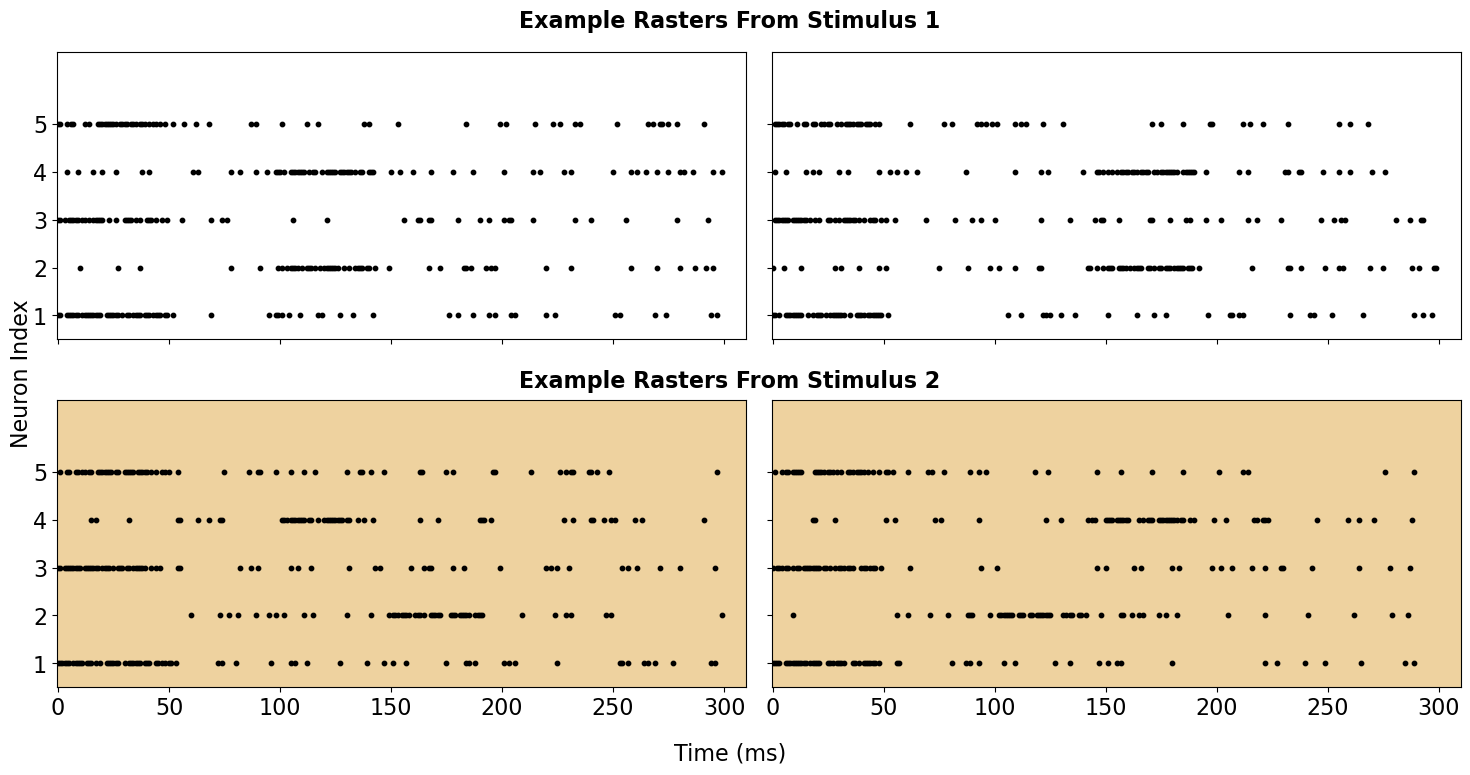

In [6]:
# random picks
random_int1, random_int2, random_int3, random_int4 = np.random.randint(
    low=0, high=n_samples_per_template-1, size=4
)

fig, axs = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)

# plot rasters and immediately clear per-axis titles/labels that plot_raster may have set
plot_raster(rasters1[random_int1], axes=axs[0, 0])
plot_raster(rasters2[random_int2], axes=axs[0, 1])
plot_raster(rasters3[random_int3], axes=axs[1, 0])
plot_raster(rasters4[random_int4], axes=axs[1, 1])

# Remove individual titles / axis label text but KEEP tick numbers
for ax in axs.flat:
    ax.set_title("")      # remove any subplot title
    ax.set_xlabel("")     # remove subplot xlabel text (but not tick numbers)
    ax.set_ylabel("")     # remove subplot ylabel text (but not tick numbers)
    ax.tick_params(axis="both", labelsize=16, which="major")  # ticks fontsize

import matplotlib.colors as mcolors
# Row background colors (distinct)
#axs[0, 0].set_facecolor(mcolors.to_rgba("#FCAA67", alpha=0.7))  # light orange w/ transparency
#axs[0, 1].set_facecolor(mcolors.to_rgba("#FCAA67", alpha=0.7))

axs[1, 0].set_facecolor(mcolors.to_rgba("#e7c077", alpha=0.7))  # dark red w/ transparency
axs[1, 1].set_facecolor(mcolors.to_rgba("#e7c077", alpha=0.7))
# Shared row subtitles (no overlap — leave room via tight_layout)
fig.text(0.5, 0.94, "Example Rasters From Stimulus 1", ha="center", va="center",
         fontsize=16, fontweight="bold")
fig.text(0.5, 0.49, "Example Rasters From Stimulus 2", ha="center", va="center",
         fontsize=16, fontweight="bold")

# Shared Y label only. (No shared X label per your request.)
fig.supylabel("Neuron Index", fontsize=16)
fig.supxlabel("Time (ms)", fontsize=16)

# Make layout room for the top subtitle and between rows
plt.tight_layout(rect=[0, 0, 1, 0.92], h_pad=4)

# plt.savefig("raster_plots.pdf", format="pdf")
# plt.savefig("raster_plots.svg", format="svg")
plt.show()


# Perform the TDA pipeline
We now perform the TDA pipeline on the dataset generated above. We report the LOOCV accuracy.

In [ ]:
labels = [0]*len(rasters_stim1) + [1] * len(rasters_stim2)

# run tda pipeline
results = TDA_pipeline(rasters = all_rasters,
                                 labels = labels,
                                 time_interval_post = [0,300],
                                 return_bdm = True,
                                 return_barcodes = True,
                                 return_DMs = True)


print('LOOCV Classification Accuracy',results['network_score'])

# TDA with Repeated Holdout Validation

In [7]:
labels = [0]*len(rasters_stim1) + [1] * len(rasters_stim2)

mean_score, bdm = tda_rhv(rasters = all_rasters,
                                 labels = labels,
                                 dim = 0,
                                 n_repeats = 20,
                                 test_size = 0.3,
                                 q =3.0,
                                 return_bdm = True) # TDA pipeline with repeated holdout validation (rhv


Building BDM: 100%|██████████| 200/200 [00:00<00:00, 752.16it/s]


In [8]:
mean_score

0.8941666666666667

## Bottleneck Distance Matrix
We visualize the resulting bottleneck distance matrix, and its corresponding MDS.

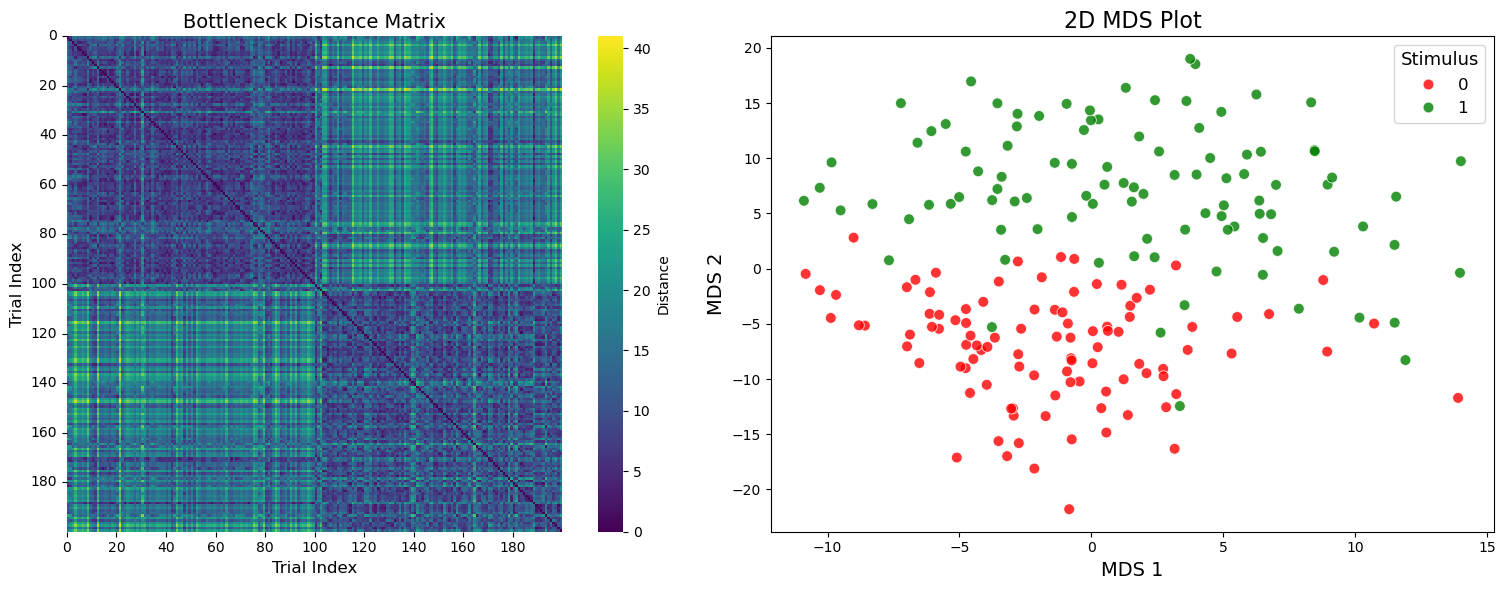

In [10]:
import seaborn as sns
import pandas as pd
from sklearn.manifold import MDS

# Compute 2D MDS from the precomputed dissimilarity matrix (bdm)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=universal_random_state, n_init=4, max_iter=300)
coords = mds.fit_transform(bdm)
labels_np = np.array(labels)

# Plot side-by-side: heatmap (BDM) and 2D MDS scatter
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Left: heatmap of the Bottleneck Distance Matrix
ax = axs[0]
sns.heatmap(bdm, cmap="viridis", square=True, cbar_kws={'label': 'Distance'}, ax=ax)
n = bdm.shape[0]
# pick a reasonable number of ticks (approx 10) to avoid crowding
ticks = list(range(0, n, max(1, n // 10)))
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=0)
ax.set_yticks(ticks)
ax.set_yticklabels(ticks, rotation=0)
ax.set_title("Bottleneck Distance Matrix", fontsize=14)
ax.set_xlabel("Trial Index", fontsize=12)
ax.set_ylabel("Trial Index", fontsize=12)

# Right: 2D MDS scatter
ax2 = axs[1]
df = pd.DataFrame({'MDS1': coords[:, 0], 'MDS2': coords[:, 1], 'Stimulus': labels_np})
sns.scatterplot(data=df, x='MDS1', y='MDS2', hue='Stimulus', palette={0: 'red', 1: 'green'}, s=60, alpha=0.8, ax=ax2)
ax2.set_xlabel('MDS 1', fontsize=14)
ax2.set_ylabel('MDS 2', fontsize=14)
ax2.set_title('2D MDS Plot', fontsize=16)
ax2.legend(title='Stimulus', fontsize=12, title_fontsize=13)
ax2.grid(False)

plt.tight_layout()
# Save combined figure
# plt.savefig("bdm_and_mds.pdf", bbox_inches='tight')
plt.show()


# Figure 4B

Code below is to reproduce Figure 4B in the paper:

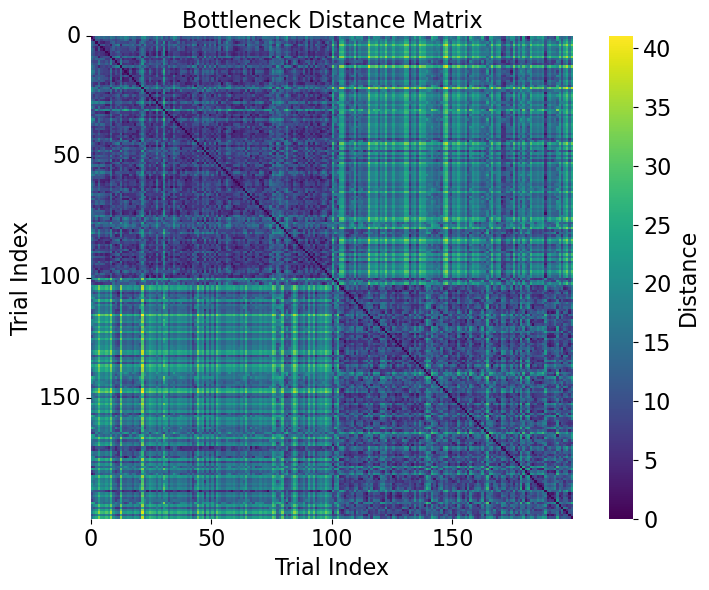

In [12]:
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    bdm,
    cmap="viridis",
    square=True,
    cbar_kws={'label': 'Distance'}
)

# show trial index every 25
n = bdm.shape[0]
ticks = list(range(0, n, 50))
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=0, fontsize=16)
ax.set_yticks(ticks)
ax.set_yticklabels(ticks, rotation=0, fontsize=16)

# Axis labels
ax.set_xlabel("Trial Index", fontsize=16)
ax.set_ylabel("Trial Index", fontsize=16)

# Colorbar label font size
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(16)
cbar.ax.tick_params(labelsize=16)  # colorbar tick labels

# Title
ax.set_title("Bottleneck Distance Matrix", fontsize=16)

plt.tight_layout()
plt.savefig("bdm_heatmap_for_5_neuron_example.pdf", bbox_inches='tight')
# plt.savefig("bdm_heatmap.svg", format="svg")
plt.show()


# Network Vs Individual Neurons

Using the same dataset, we now examine individual neurons and compare them with the network. For each neuron, we extract all of its spike trains and, using the Victor–Purpura (VP) distance, construct its VP distance matrix. We then perform 1-NN with LOOCV to obtain a classification score for each neuron. The process is outlined in detail in **Appendix B1** of the paper.

In [14]:
# extract single neuron responses
neuron_0_responses = np.array([all_rasters[i][0] for i in range(len(all_rasters))])
neuron_1_responses = np.array([all_rasters[i][1] for i in range(len(all_rasters))])
neuron_2_responses = np.array([all_rasters[i][2] for i in range(len(all_rasters))])
neuron_3_responses = np.array([all_rasters[i][3] for i in range(len(all_rasters))])
neuron_4_responses = np.array([all_rasters[i][4] for i in range(len(all_rasters))])

# construct VP distance matrices for each neuron
vpdm_n0 = VP_trivial(neuron_0_responses)
vpdm_n1 = VP_trivial(neuron_1_responses)
vpdm_n2 = VP_trivial(neuron_2_responses)
vpdm_n3 = VP_trivial(neuron_3_responses)
vpdm_n4 = VP_trivial(neuron_4_responses)

# prep for loo
n_samples_per_stimulus = 2* n_samples_per_template # we usee 100 per stimulus
labels = np.array([0]*n_samples_per_stimulus + [1]* n_samples_per_stimulus)
trial_meta = [(stim_id,trial_id) for stim_id in [0,1] for trial_id in range(n_samples_per_stimulus)]

# perform LOO for each neuron
loo_results_n0 = np.round(LeaveOneOut(vpdm_n0,labels,trial_meta = trial_meta)['accuracy_score'],3)
loo_results_n1 = np.round(LeaveOneOut(vpdm_n1,labels,trial_meta = trial_meta)['accuracy_score'],3) 
loo_results_n2 = np.round(LeaveOneOut(vpdm_n2,labels,trial_meta = trial_meta)['accuracy_score'],3) 
loo_results_n3 = np.round(LeaveOneOut(vpdm_n3,labels,trial_meta = trial_meta)['accuracy_score'],3)
loo_results_n4 = np.round(LeaveOneOut(vpdm_n4,labels,trial_meta = trial_meta)['accuracy_score'],3)
network_score = mean_score

# save and report all results
all_results_df = pd.DataFrame({'Network Score':[network_score],
                               'Neuron 0':[loo_results_n0],
                               'Neuron 1':[loo_results_n1],
                               'Neuron 2':[loo_results_n2],
                               'Neuron 3':[loo_results_n3],
                               'Neuron 4':[loo_results_n4],                          
})
                          
from IPython.display import display
display(all_results_df)


,Network Score,Neuron 0,Neuron 1,Neuron 2,Neuron 3,Neuron 4
0,0.894167,0.5,0.5,0.525,0.455,0.435


# Multiple runs

This dataset was generated with a fixed random seed, which we refer to as a single run. Below, we provide code for performing multiple runs if desired (by default, we execute only one run here).

In [22]:
from tqdm import tqdm

def run_single_experiment(universal_random_state, n_samples_per_template, noise_params=None):
    """
    Encapsulates a complete experimental run for a given random seed, sample size, and noise configuration.

    This function performs the following steps:
    1. Generates a set of base "template" spike trains.
    2. Assembles these spike trains into "raster templates" for two different stimuli.
    3. Creates a dataset of noisy rasters by adding specified noise to the templates.
    4. Runs the TDA pipeline on the entire dataset to get a "network score".
    5. Calculates the classification accuracy for each individual neuron.
    
    Args:
        universal_random_state (int): The seed for the random number generator to ensure reproducibility.
        n_samples_per_template (int): The number of noisy raster samples to generate from each template.
        noise_params (dict, optional): A dictionary specifying the noise parameters. 
                                       If None, baseline defaults are used.
                                       Keys: 'noise_level_remove', 'noise_level_shift', 
                                             'shift_strength', 'noise_level_add'.

    Returns:
        tuple: A tuple containing:
            - network_score (float): The classification accuracy using the TDA pipeline on the whole network.
            - individual_neuron_scores (list): A list of classification accuracies for each neuron individually.
    """
    if noise_params is None:
        noise_params = {
            'noise_level_remove': 0.1,  # Probability of removing an existing spike
            'noise_level_shift': 1.0,   # Probability of shifting an existing spike
            'shift_strength': 5,        # Max temporal shift (in ms) for a spike
            'noise_level_add': 0.1      # Probability of adding a new spike per time bin
        }

    fire_rate = 0.7
    st_temp1 = gen_spike_train(T=300, prob_map=[(0, 50, fire_rate)], random_state=universal_random_state + 1)
    st_temp2 = gen_spike_train(T=300, prob_map=[(0, 50, fire_rate)], random_state=universal_random_state + 2)
    st_temp3 = gen_spike_train(T=300, prob_map=[(0, 50, fire_rate)], random_state=universal_random_state + 3)
    st_temp4 = gen_spike_train(T=300, prob_map=[(100, 140, fire_rate)], random_state=universal_random_state + 4)
    st_temp5 = gen_spike_train(T=300, prob_map=[(100, 140, fire_rate)], random_state=universal_random_state + 5)
    st_temp6 = shift_spike_train(st_temp4, shift_amount=50)  # A time-shifted version of template 4
    st_temp7 = shift_spike_train(st_temp5, shift_amount=50)  # A time-shifted version of template 5

    # assemble the spike trains into multi-neuron raster plots.
    # These represent the "perfect" or "ideal" neural response to each stimulus.
    raster_temp1 = np.array([st_temp1, st_temp4, st_temp2, st_temp5, st_temp3]) # Stimulus 1, Template A
    raster_temp2 = np.array([st_temp1, st_temp6, st_temp2, st_temp7, st_temp3]) # Stimulus 1, Template B
    raster_temp3 = np.array([st_temp1, st_temp6, st_temp2, st_temp5, st_temp3]) # Stimulus 2, Template A
    raster_temp4 = np.array([st_temp1, st_temp4, st_temp2, st_temp7, st_temp3]) # Stimulus 2, Template B
    rng = np.random.default_rng(universal_random_state)
    


    # Create a large pool of unique numbers and shuffle it
    total_samples = 4 * n_samples_per_template
    shuffled_pool = rng.permutation(total_samples)

    # Split the shuffled pool into four disjoint lists of random seeds
    random_list1, random_list2, random_list3, random_list4 = np.split(shuffled_pool, 4)
    random_list = rng.choice(n_samples_per_template, size=n_samples_per_template, replace=False) # list of random seeds. This is also reproducible with the universal_random_state.

    # parameters for noise addition
    # the noise order is Remove -> Shift -> Add
    noise_level_remove = 0.1 # probability of each spike being removed
    noise_level_shift = 1.0 # probability of each spike being shifted
    shift_strength = 5 # bounds of the shift in ms; if shift_strength = 5, then each spike can be shifted by x ms where x is uniformly sampled from [-5, 5].
    noise_level_add = 0.1 # probability of a spike being added to an empty time slot.

    # stim 1 rasters
    rasters1 = [add_noise_to_raster(raster_temp1,noise_level_shift=noise_level_shift,shift_strength= shift_strength, noise_level_add= noise_level_add, noise_level_remove= noise_level_remove,random_state = random_seed) for random_seed in random_list1]
    rasters2 = [add_noise_to_raster(raster_temp2,noise_level_shift=noise_level_shift,shift_strength= shift_strength, noise_level_add= noise_level_add, noise_level_remove= noise_level_remove,random_state = random_seed) for random_seed in random_list2]
    rasters_stim1 = rasters1 + rasters2

    # stim 2 rasters
    rasters3 = [add_noise_to_raster(raster_temp3,noise_level_shift=noise_level_shift,shift_strength= shift_strength, noise_level_add= noise_level_add, noise_level_remove= noise_level_remove,random_state = random_seed) for random_seed in random_list3]
    rasters4 = [add_noise_to_raster(raster_temp4,noise_level_shift=noise_level_shift,shift_strength= shift_strength, noise_level_add= noise_level_add, noise_level_remove= noise_level_remove,random_state = random_seed) for random_seed in random_list4]
    rasters_stim2 = rasters3 + rasters4

    all_rasters = rasters_stim1 + rasters_stim2 # this is our dataset now.

    # prep for LOO
    labels = [0] * len(rasters_stim1) + [1] * len(rasters_stim2)
    network_score,bdm = tda_rhv(rasters=all_rasters, labels=labels, return_bdm=True)
    

    num_neurons = len(all_rasters[0])
    neuron_responses = [np.array([raster[i] for raster in all_rasters]) for i in range(num_neurons)]

    # Compute the distance matrices for each neuron
    vp_distance_matrices = [VP_trivial(responses) for responses in neuron_responses]

    n_samples_per_stimulus = 2 * n_samples_per_template
    labels_np = np.array([0] * n_samples_per_stimulus + [1] * n_samples_per_stimulus)

    # --- New Repeated Holdout Validation Logic ---
    n_repeats = 20
    test_size = 0.3
    random_state = 42 # For reproducibility

    splitter = StratifiedShuffleSplit(n_splits=n_repeats, test_size=test_size, random_state=random_state)

    individual_neuron_scores = []

    # Iterate through each neuron's precomputed distance matrix
    for vpdm in vp_distance_matrices:
        split_scores = []
        
        # Run the 20 splits for the current neuron
        for train_idx, test_idx in splitter.split(np.zeros_like(labels_np), labels_np):
            
            # Slice the precomputed distance matrix for train/test
            D_train = vpdm[np.ix_(train_idx, train_idx)]
            D_test = vpdm[np.ix_(test_idx, train_idx)]

            # Initialize and fit the 1-NN classifier
            knn = KNeighborsClassifier(n_neighbors=1, metric="precomputed")
            knn.fit(D_train, labels_np[train_idx])
            preds = knn.predict(D_test)

            # Calculate and store the accuracy for this split
            split_scores.append(accuracy_score(labels_np[test_idx], preds))
            
        # Calculate the mean across the 20 repeats, round it, and store for this neuron
        mean_score = np.round(np.mean(split_scores), 3)
        individual_neuron_scores.append(mean_score)
    
    return network_score, individual_neuron_scores

Running experiment for 1 different random seeds...


100%|██████████| 1/1 [00:01<00:00,  1.61s/it]


--- Robustness Check Results ---
Ran 1 experiments with different random seeds.
Mean Network Accuracy: 0.894
Mean Single Neuron Accuracy: [0.48  0.504 0.538 0.446 0.449]


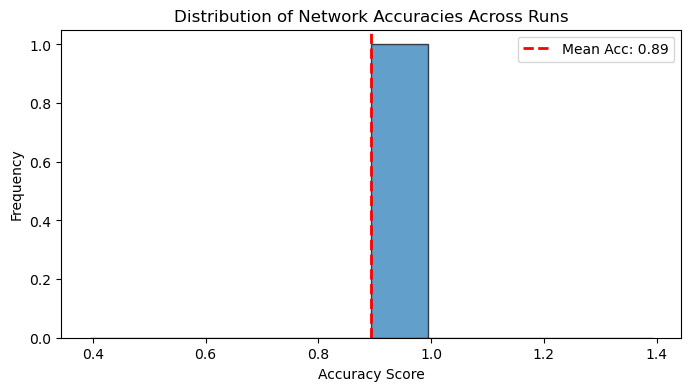

In [ ]:
# code changed Dec 8 monday
# using 50 samples per template instead of 200. That is 100 per stimulus.
n_runs = 1  # Number of different random seeds to try == number of realizations
network_scores, single_neuron_scores = [], [] 
print(f"Running experiment for {n_runs} different random seeds...")
for i in tqdm(range(1, n_runs + 1)):
    # Each run gets a different seed starting from 1
    n_score, sns = run_single_experiment(universal_random_state=i,n_samples_per_template=50) # network score and single neuron score
    network_scores.append(n_score)
    single_neuron_scores.append(sns)

# --- Report Final, Robust Results ---
mean_accuracy_network = np.mean(network_scores)
std_accuracy_network = np.std(network_scores)

mean_accuracy_sn = np.mean(single_neuron_scores, axis = 0)
std_accuracy_sn = np.std(single_neuron_scores, axis = 0)

print("\n--- Robustness Check Results ---")
print(f"Ran {n_runs} experiments with different random seeds.")
print(f"Mean Network Accuracy: {mean_accuracy_network:.3f}")
print(f"Mean Single Neuron Accuracy: {mean_accuracy_sn}")



# Visualize the distribution of scores
plt.figure(figsize=(8, 4))
plt.hist(network_scores, bins=10, edgecolor='k', alpha=0.7)
plt.axvline(mean_accuracy_network, color='red', linestyle='--', lw=2, label=f'Mean Acc: {mean_accuracy_network:.2f}')
plt.title('Distribution of Network Accuracies Across Runs')
plt.xlabel('Accuracy Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Figure 4C

Code below is to reproduce Figure 4C in the paper.

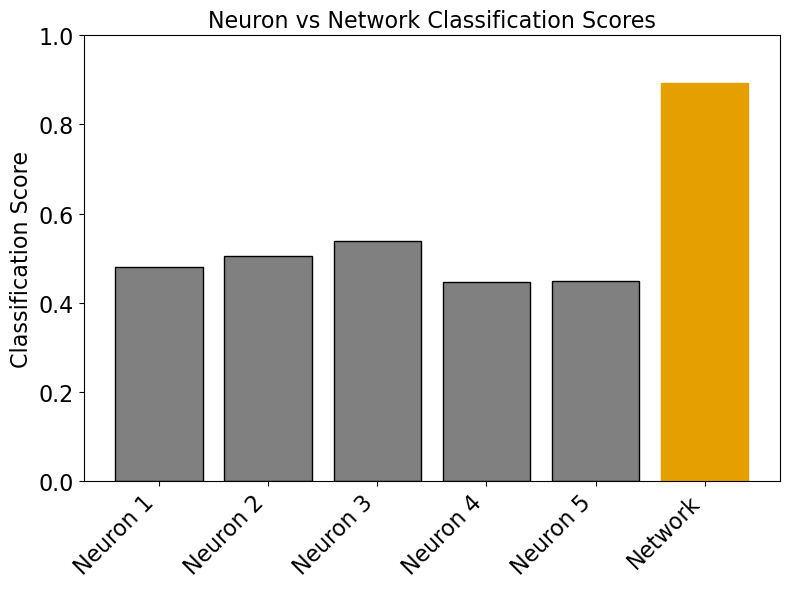

In [24]:
neuron_scores = np.array(single_neuron_scores[0]) # [0.48  0.504 0.538 0.446 0.449]
network_score = network_scores[0] #0.894                            

scores = np.concatenate([neuron_scores, [network_score]])
labels = [f"Neuron {i}" for i in range(1, len(neuron_scores)+1)] + ["Network"]

x = np.arange(len(labels))

plt.figure(figsize=(8,6))
bars = plt.bar(x, scores, capsize=5, color='grey', edgecolor='black')
bars[-1].set_color('#e69f00')

plt.xticks(x, labels, rotation=45, ha='right', fontsize=16)
plt.ylabel("Classification Score", fontsize=16)
plt.title("Neuron vs Network Classification Scores", fontsize=16)
plt.ylim(0, 1)
plt.yticks(fontsize=16)
plt.tight_layout()

plt.savefig("score_barchart_for_5_neuron_example.pdf", bbox_inches='tight')
# plt.savefig("score_barchart.svg", format="svg")
plt.show()
